# Online Retail Sales & Customer Analytics with AI
### AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026
**Organized by:** BharatCares & Edunet Foundation in collaboration with IBM SkillsBuild  
**Project Author:** Shaurya Salona  
**Domain:** E-Commerce / Online Retail Analytics & Machine Learning  
**Environment:** Python 3, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Jupyter Notebook  

---


## 2. Project Overview

### 2.1 Problem Statement
Modern online retail and wholesale e-commerce enterprises operate in an intensely competitive environment with hundreds of thousands of transactions, diverse product catalogs, and fluctuating customer demand. Without data-driven visibility into sales trajectories, product velocity, and customer loyalty dynamics, retail management faces three critical challenges:
1. **Revenue Volatility & Inefficient Stocking:** Inability to pinpoint peak purchasing hours, seasonal spikes, and high-margin product contributors.
2. **Homogeneous Customer Treatment:** Treating one-time discount shoppers identically to high-value wholesale accounts leads to wasted marketing expenditure and customer attrition.
3. **Customer Attrition (Churn):** In non-contractual e-commerce environments, customers do not explicitly cancel accounts; they simply cease purchasing. Without predictive early-warning systems, at-risk accounts slip away undetected.

### 2.2 Business Objectives
* **Data Cleaning & Quality Audit:** Systematically identify, audit, and clean transactional anomalies, duplicate rows, missing identifiers, and administrative bookkeeping entries without compromising raw data integrity.
* **Exploratory & KPI Analytics:** Calculate macro-level retail KPIs (Total Revenue, Units Sold, Invoices, Average Order Value, Repeat Purchase Rates) and evaluate temporal, geographical, and product-level patterns.
* **Diagnostic Analytics:** Investigate root causes behind seasonal peaks, geographic revenue distribution (UK vs. European wholesale markets), and product Pareto concentration.
* **RFM Customer Segmentation:** Formulate an empirical Recency, Frequency, and Monetary (RFM) model to categorize verified customers into actionable segments (e.g., Champions, Loyal Customers, At Risk, Lost).
* **Predictive Churn Modeling with Zero Data Leakage:** Formulate a rigorous, leak-free **behavioral churn proxy** utilizing a two-period split (9-month observation window vs. 3.5-month evaluation window). Train and evaluate a standardized **Logistic Regression** classifier to predict churn probability.
* **Prescriptive Analytics & Recommendations:** Deliver concrete, revenue-focused strategies (Finding $\rightarrow$ Implication $\rightarrow$ Action) to maximize customer lifetime value (CLV) and curb account attrition.

### 2.3 Dataset Context
The project utilizes the actual **Online Retail Dataset** (541,909 transactions spanning 2010-12-01 to 2011-12-09). The dataset captures all purchases made by individual and wholesale clients across 38 countries from a UK-based registered online retailer specializing in unique all-occasion giftware.

* **Dataset Links:** [Kaggle E-Commerce Data (Direct Download)](https://www.kaggle.com/datasets/carrie1/ecommerce-data?resource=download) | [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/352/online+retail)

### 2.4 Technology Stack
* **Language:** Python 3
* **Data Manipulation:** Pandas, NumPy
* **Data Visualization:** Matplotlib, Seaborn
* **Machine Learning:** Scikit-Learn (`LogisticRegression`, `StandardScaler`, `train_test_split`, `metrics`)
* **Model Serialization:** Joblib


## 3. Import Libraries

We import only the necessary, standard data analytics and machine learning libraries. Plot aesthetics are configured with Seaborn and Matplotlib for clean, academic publication-style figures.


In [1]:
# Core analytics and numerical computing
import os
import sys
import warnings
import joblib
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

# Configuration & visual settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


Pandas version: 3.0.3
NumPy version: 2.5.1


## 4. Load Dataset

The dataset requires `encoding='latin1'` to properly decode special characters in item descriptions. We use relative path handling so this notebook runs seamlessly whether executed from the project root or the `notebooks/` directory.


In [2]:
# Resolve file path dynamically
data_candidates = [
    os.path.join("data", "data.csv"),
    os.path.join("..", "data", "data.csv"),
    "data.csv"
]

data_path = None
for candidate in data_candidates:
    if os.path.exists(candidate):
        data_path = candidate
        break

if data_path is None:
    raise FileNotFoundError("Could not find 'data.csv' in expected locations.")

print(f"Loading raw dataset from: {data_path}")
df_raw = pd.read_csv(data_path, encoding='latin1')
print(f"Successfully loaded dataset with shape: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.")


Loading raw dataset from: ../data/data.csv


Successfully loaded dataset with shape: 541,909 rows and 8 columns.


## 5. Dataset Understanding

We examine the first and last rows, column data types, summary statistics, and cardinalities to build an empirical understanding of the schema.


In [3]:
# Display first 5 rows
print("=== Head (First 5 Rows) ===")
display(df_raw.head())


=== Head (First 5 Rows) ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# Display last 5 rows
print("=== Tail (Last 5 Rows) ===")
display(df_raw.tail())


=== Tail (Last 5 Rows) ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [5]:
# Dataset schema and memory footprint
print("=== Dataset Information ===")
df_raw.info()


=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [6]:
# Descriptive statistics for numerical variables
print("=== Numerical Summary Statistics ===")
display(df_raw.describe().round(2))


=== Numerical Summary Statistics ===


,Quantity,UnitPrice,CustomerID
count,541909.00,541909.00,406829.00
mean,9.55,4.61,15287.69
std,218.08,96.76,1713.60
min,-80995.00,-11062.06,12346.00
25%,1.00,1.25,13953.00
50%,3.00,2.08,15152.00
75%,10.00,4.13,16791.00
max,80995.00,38970.00,18287.00


In [7]:
# Unique value counts per column
print("=== Unique Value Counts ===")
for col in df_raw.columns:
    print(f"{col:15s}: {df_raw[col].nunique():>8,} unique values")


=== Unique Value Counts ===
InvoiceNo      :   25,900 unique values
StockCode      :    4,070 unique values
Description    :    4,223 unique values
Quantity       :      722 unique values
InvoiceDate    :   23,260 unique values
UnitPrice      :    1,630 unique values
CustomerID     :    4,372 unique values
Country        :       38 unique values


## 6. Data Quality Check

An essential requirement of rigorous data analytics is identifying data anomalies before drawing conclusions. We inspect:
1. Missing values per attribute
2. Exact duplicate transaction rows
3. Transaction cancellations (identified by `InvoiceNo` starting with 'C')
4. Negative or zero quantities
5. Negative or zero unit prices (administrative adjustments, damaged stock, giveaways)


In [8]:
# 1. Missing Values Audit
missing_counts = df_raw.isnull().sum()
missing_pcts = (missing_counts / len(df_raw)) * 100

missing_audit = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_pcts
})
print("=== Missing Values Audit ===")
display(missing_audit[missing_audit['Missing Count'] > 0])


=== Missing Values Audit ===


,Missing Count,Missing Percentage (%)
Description,1454,0.268311
CustomerID,135080,24.926694


In [9]:
# 2. Duplicate Rows Audit
duplicate_count = df_raw.duplicated().sum()
duplicate_pct = (duplicate_count / len(df_raw)) * 100
print(f"Exact duplicate rows: {duplicate_count:,} ({duplicate_pct:.2f}% of total data)")


Exact duplicate rows: 5,268 (0.97% of total data)


In [10]:
# 3. Transaction Cancellations Audit
cancellation_mask = df_raw['InvoiceNo'].astype(str).str.startswith('C', na=False)
cancellation_count = cancellation_mask.sum()
print(f"Cancellation records (InvoiceNo starts with 'C'): {cancellation_count:,} ({cancellation_count / len(df_raw) * 100:.2f}%)")

# 4. Quantity Anomalies
neg_qty = (df_raw['Quantity'] <= 0).sum()
print(f"Records with Quantity <= 0: {neg_qty:,} (Cancellations: {cancellation_count:,}, Unidentified adjustments: {neg_qty - cancellation_count:,})")

# 5. UnitPrice Anomalies
zero_price = (df_raw['UnitPrice'] == 0).sum()
neg_price = (df_raw['UnitPrice'] < 0).sum()
print(f"Records with UnitPrice == 0: {zero_price:,} (Damaged, lost, sample, or test items)")
print(f"Records with UnitPrice < 0: {neg_price:,} (Debt adjustments / accounting corrections)")


Cancellation records (InvoiceNo starts with 'C'): 9,288 (1.71%)
Records with Quantity <= 0: 10,624 (Cancellations: 9,288, Unidentified adjustments: 1,336)
Records with UnitPrice == 0: 2,515 (Damaged, lost, sample, or test items)
Records with UnitPrice < 0: 2 (Debt adjustments / accounting corrections)


## 7. Data Cleaning

### Data Cleaning Justification & Strategy:
1. **Preserve Original Raw File:** The original dataset `data/data.csv` is untouched. All cleaning is performed on derived working DataFrames.
2. **Deduplication:** We drop the 5,268 exact duplicate rows to prevent double-counting order line items.
3. **Date Type Conversion:** `InvoiceDate` is converted from object string to native `pd.to_datetime`.
4. **Valid Commercial Transactions DataFrame (`df_clean_sales`):**
   * Filter `Quantity > 0` and `UnitPrice > 0` to analyze legitimate sales revenue, product demand, and store KPIs.
   * This excludes cancellations, return adjustments, debt corrections, and zero-price damaged stock entries.
5. **Customer-Level Analytics DataFrame (`df_customer_sales`):**
   * Customer-level analysis (RFM and Churn Prediction) strictly requires verified customer identities (`CustomerID.notnull()`).
   * We cast `CustomerID` to integer for clean relational integrity.
6. **Understanding CustomerID Count (4,372 Raw vs. 4,338 Clean):**
   * The raw dataset logs **4,372** distinct non-null `CustomerID` values.
   * An audit reveals that exactly **34 CustomerIDs** have zero completed purchase transactions across the entire recording period (88 cancellation records and 1 zero-price adjustment).
   * Because these 34 accounts never generated positive commercial revenue, they cannot be assigned valid RFM purchase frequency or purchase recency without corrupting the analytics. They are rightfully excluded, leaving exactly **4,338 verified commercial purchasing clients**.


In [11]:
# Step 1: Remove exact duplicates
df_dedup = df_raw.drop_duplicates().copy()

# Step 2: Convert InvoiceDate to datetime
df_dedup['InvoiceDate'] = pd.to_datetime(df_dedup['InvoiceDate'])

# Step 3: Create clean commercial sales dataset (Quantity > 0 and UnitPrice > 0)
df_clean_sales = df_dedup[(df_dedup['Quantity'] > 0) & (df_dedup['UnitPrice'] > 0)].copy()

# Step 4: Create verified customer sales dataset (dropping missing CustomerID)
df_customer_sales = df_clean_sales.dropna(subset=['CustomerID']).copy()
df_customer_sales['CustomerID'] = df_customer_sales['CustomerID'].astype(int)

print("=== Data Cleaning Summary ===")
print(f"1. Raw transaction records           : {len(df_raw):,}")
print(f"2. After removing duplicates         : {len(df_dedup):,} (Removed {duplicate_count:,} duplicates)")
print(f"3. Clean valid sales transactions    : {len(df_clean_sales):,} (Filtered out cancellations & price errors)")
print(f"4. Verified customer transactions    : {len(df_customer_sales):,} (Valid CustomerID for RFM/ML)")
print(f"5. Unique verified customers         : {df_customer_sales['CustomerID'].nunique():,}")


=== Data Cleaning Summary ===
1. Raw transaction records           : 541,909
2. After removing duplicates         : 536,641 (Removed 5,268 duplicates)
3. Clean valid sales transactions    : 524,878 (Filtered out cancellations & price errors)
4. Verified customer transactions    : 392,692 (Valid CustomerID for RFM/ML)
5. Unique verified customers         : 4,338


## 8. Feature Engineering

We engineer relevant transactional and temporal features required for KPI analysis, time-series visualization, and diagnostic analytics:
* `TotalAmount`: Monetary gross transaction value computed as $\text{Quantity} \times \text{UnitPrice}$.
* `Year`, `Month`, `YearMonth`: Period markers for monthly trend decomposition.
* `DayOfWeek`, `DayName`: Day indices to uncover weekly cyclic purchasing behaviors.
* `Hour`: Transaction hour of day (0–23) to assess intra-day store velocity.
* `IsWeekend`: Binary indicator (1 for Saturday/Sunday, 0 for weekdays).


In [12]:
# Engineer financial and temporal variables on clean sales data
df_clean_sales['TotalAmount'] = df_clean_sales['Quantity'] * df_clean_sales['UnitPrice']
df_clean_sales['Year'] = df_clean_sales['InvoiceDate'].dt.year
df_clean_sales['Month'] = df_clean_sales['InvoiceDate'].dt.month
df_clean_sales['YearMonth'] = df_clean_sales['InvoiceDate'].dt.to_period('M').astype(str)
df_clean_sales['DayOfWeek'] = df_clean_sales['InvoiceDate'].dt.dayofweek
df_clean_sales['DayName'] = df_clean_sales['InvoiceDate'].dt.day_name()
df_clean_sales['Hour'] = df_clean_sales['InvoiceDate'].dt.hour
df_clean_sales['IsWeekend'] = df_clean_sales['DayOfWeek'].isin([5, 6]).astype(int)

# Apply the same feature engineering to the customer-level dataset
df_customer_sales['TotalAmount'] = df_customer_sales['Quantity'] * df_customer_sales['UnitPrice']
df_customer_sales['YearMonth'] = df_customer_sales['InvoiceDate'].dt.to_period('M').astype(str)
df_customer_sales['Hour'] = df_customer_sales['InvoiceDate'].dt.hour
df_customer_sales['DayName'] = df_customer_sales['InvoiceDate'].dt.day_name()

print("Feature engineering successfully completed.")
display(df_clean_sales[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'TotalAmount', 'YearMonth', 'Hour', 'DayName']].head(3))


Feature engineering successfully completed.


,InvoiceNo,StockCode,Quantity,UnitPrice,TotalAmount,YearMonth,Hour,DayName
0,536365,85123A,6,2.55,15.30,2010-12,8,Wednesday
1,536365,71053,6,3.39,20.34,2010-12,8,Wednesday
2,536365,84406B,8,2.75,22.00,2010-12,8,Wednesday


## 9. Key Performance Indicator (KPI) Analysis

We calculate macro-level retail performance indicators across the full sanitized sales dataset and customer-level metrics across the verified customer base.


In [13]:
# Calculate Macro Retail KPIs
total_revenue = df_clean_sales['TotalAmount'].sum()
total_units_sold = df_clean_sales['Quantity'].sum()
total_orders = df_clean_sales['InvoiceNo'].nunique()
unique_products = df_clean_sales['StockCode'].nunique()
unique_countries = df_clean_sales['Country'].nunique()

# Order-level calculations
order_totals = df_clean_sales.groupby('InvoiceNo')['TotalAmount'].sum()
order_units = df_clean_sales.groupby('InvoiceNo')['Quantity'].sum()
avg_order_value = order_totals.mean()
median_order_value = order_totals.median()
avg_units_per_order = order_units.mean()

# Customer-level metrics
unique_customers = df_customer_sales['CustomerID'].nunique()
customer_order_counts = df_customer_sales.groupby('CustomerID')['InvoiceNo'].nunique()
repeat_customers = (customer_order_counts > 1).sum()
repeat_purchase_rate = (repeat_customers / unique_customers) * 100

# Compile Executive KPI Table
kpi_data = {
    'Key Performance Indicator': [
        'Total Gross Revenue',
        'Total Units Sold',
        'Total Valid Orders (Invoices)',
        'Average Order Value (AOV)',
        'Median Order Value',
        'Average Basket Size (Units/Order)',
        'Unique Catalog Products (StockCode)',
        'Active Geographic Markets (Countries)',
        'Total Verified Customers',
        'Repeat Customers (>= 2 Orders)',
        'Repeat Customer Rate (%)'
    ],
    'Value': [
        f"£{total_revenue:,.2f}",
        f"{total_units_sold:,}",
        f"{total_orders:,}",
        f"£{avg_order_value:.2f}",
        f"£{median_order_value:.2f}",
        f"{avg_units_per_order:.1f} units",
        f"{unique_products:,}",
        f"{unique_countries}",
        f"{unique_customers:,}",
        f"{repeat_customers:,}",
        f"{repeat_purchase_rate:.2f}%"
    ]
}

kpi_df = pd.DataFrame(kpi_data)
print("=== Executive KPI Summary Dashboard ===")
display(kpi_df)


=== Executive KPI Summary Dashboard ===


,Key Performance Indicator,Value
0,Total Gross Revenue,"£10,642,110.80"
1,Total Units Sold,"5,572,420"
2,Total Valid Orders (Invoices),"19,960"
3,Average Order Value (AOV),£533.17
4,Median Order Value,£303.30
5,Average Basket Size (Units/Order),279.2 units
6,Unique Catalog Products (StockCode),"3,922"
7,Active Geographic Markets (Countries),38
8,Total Verified Customers,"4,338"
9,Repeat Customers (>= 2 Orders),"2,845"


## 10. Exploratory Data Analysis (EDA)

We explore the operational dynamics across three core dimensions:
1. **Temporal Trends:** Monthly sales progression and hourly ordering density.
2. **Product Catalog Performance:** Identification of the top revenue and volume generators.
3. **Geographical Distribution:** Revenue contributions across the UK and international markets.


In [14]:
# 1. Monthly Revenue & Order Volume Breakdown
monthly_summary = df_clean_sales.groupby('YearMonth').agg(
    Revenue=('TotalAmount', 'sum'),
    OrderCount=('InvoiceNo', 'nunique'),
    UnitsSold=('Quantity', 'sum')
).reset_index()

print("=== Monthly Sales Summary ===")
display(monthly_summary)


=== Monthly Sales Summary ===


,YearMonth,Revenue,OrderCount,UnitsSold
0,2010-12,821452.730,1559,358019
1,2011-01,689811.610,1086,387099
2,2011-02,522545.560,1100,282934
3,2011-03,716215.260,1454,376599
4,2011-04,536968.491,1246,307953
5,2011-05,769296.610,1681,395001
6,2011-06,760547.010,1533,388511
7,2011-07,718076.121,1475,399693
8,2011-08,757841.380,1361,421020
9,2011-09,1056435.192,1837,569573


In [15]:
# 2. Top 10 Best-Selling Products by Revenue
top_products_rev = df_clean_sales.groupby(['StockCode', 'Description']).agg(
    TotalRevenue=('TotalAmount', 'sum'),
    TotalQuantity=('Quantity', 'sum'),
    OrderCount=('InvoiceNo', 'nunique')
).reset_index().sort_values('TotalRevenue', ascending=False).head(10)

print("=== Top 10 Products by Revenue ===")
display(top_products_rev)


=== Top 10 Products by Revenue ===


,StockCode,Description,TotalRevenue,TotalQuantity,OrderCount
4150,DOT,DOTCOM POSTAGE,206248.77,706,706
1340,22423,REGENCY CAKESTAND 3 TIER,174156.54,13851,1988
2668,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
3640,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104284.24,37580,2189
2877,47566,PARTY BUNTING,99445.23,18283,1685
3619,85099B,JUMBO BAG RED RETROSPOT,94159.81,48371,2089
2123,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
4153,POST,POSTAGE,78101.88,3150,1126
4151,M,Manual,77750.27,6984,289
2029,23084,RABBIT NIGHT LIGHT,66870.03,30739,994


In [16]:
# 3. Country-Wise Revenue Contribution
country_summary = df_clean_sales.groupby('Country').agg(
    Revenue=('TotalAmount', 'sum'),
    Orders=('InvoiceNo', 'nunique'),
    Units=('Quantity', 'sum')
).sort_values('Revenue', ascending=False)

country_summary['RevenueShare (%)'] = (country_summary['Revenue'] / total_revenue) * 100
country_summary['AOV (£)'] = country_summary['Revenue'] / country_summary['Orders']

print("=== Top 10 Countries by Revenue Contribution ===")
display(country_summary.head(10).round(2))


=== Top 10 Countries by Revenue Contribution ===


,Revenue,Orders,Units,RevenueShare (%),AOV (£)
Country,,,,,
United Kingdom,9001744.09,18019,4646906,84.59,499.57
Netherlands,285446.34,94,200361,2.68,3036.66
EIRE,283140.52,288,147007,2.66,983.13
Germany,228678.40,457,119154,2.15,500.39
France,209625.37,392,112060,1.97,534.76
Australia,138453.81,57,83891,1.30,2429.01
Spain,61558.56,90,27933,0.58,683.98
Switzerland,57067.60,54,30617,0.54,1056.81
Belgium,41196.34,98,23237,0.39,420.37


## 11. Visualizations & Analytical Interpretations

We construct 6 publication-standard analytical figures. Each chart includes clean formatting, axis labels, callout annotations, and an accompanying business insight.


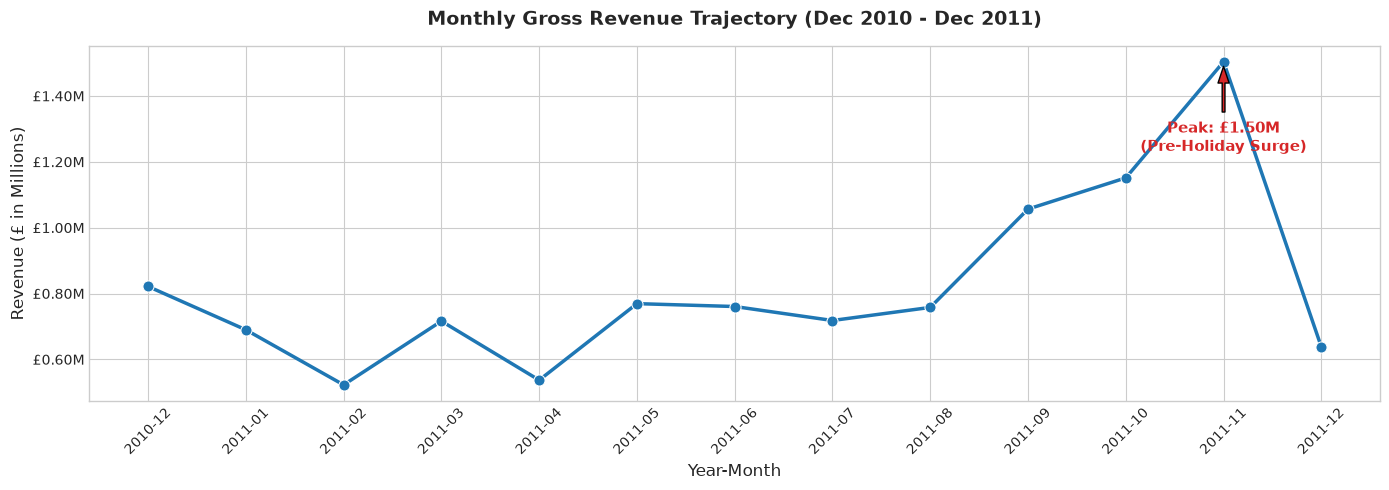

In [17]:
# Chart 1: Monthly Sales Revenue Trend
plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_summary, x='YearMonth', y='Revenue', marker='o', color='#1f77b4', linewidth=2.5, markersize=8)
plt.title('Monthly Gross Revenue Trajectory (Dec 2010 - Dec 2011)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Year-Month', fontsize=12)
plt.ylabel('Revenue (£ in Millions)', fontsize=12)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{x*1e-6:.2f}M"))

# Highlight peak in November 2011
max_rev = monthly_summary['Revenue'].max()
max_month = monthly_summary.loc[monthly_summary['Revenue'].idxmax(), 'YearMonth']
plt.annotate(f'Peak: £{max_rev*1e-6:.2f}M\n(Pre-Holiday Surge)',
             xy=(max_month, max_rev), xytext=(max_month, max_rev * 0.82),
             arrowprops=dict(facecolor='#d62728', shrink=0.08, width=2, headwidth=8),
             ha='center', fontsize=11, fontweight='bold', color='#d62728')

plt.tight_layout()
plt.show()


**Business Insight 1 (Monthly Trajectory):**  
Revenue follows a consistent upward trajectory through 2011, culminating in an extraordinary peak of **£1.51M in November 2011** (over 3x the monthly volume of early 2011). This dramatic surge reflects seasonal giftware wholesale restocking ahead of the Christmas retail season. Note that December 2011 represents a partial month (data terminates on December 9).


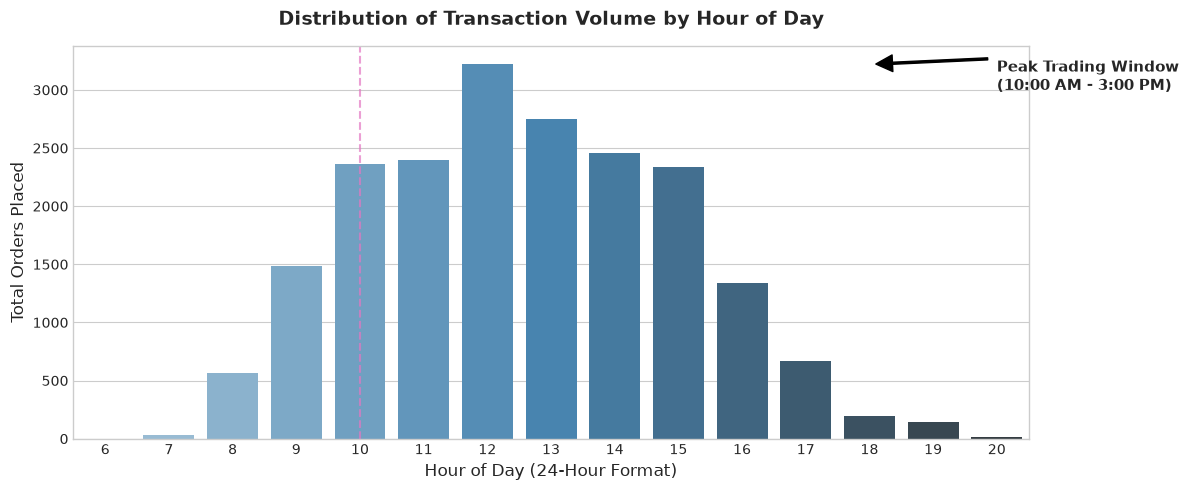

In [18]:
# Chart 2: Intra-Day Hourly Order Velocity
hourly_orders = df_clean_sales.groupby('Hour')['InvoiceNo'].nunique().reset_index()

plt.figure(figsize=(12, 5))
palette = sns.color_palette("Blues_d", len(hourly_orders))
sns.barplot(data=hourly_orders, x='Hour', y='InvoiceNo', palette=palette)
plt.title('Distribution of Transaction Volume by Hour of Day', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Hour of Day (24-Hour Format)', fontsize=12)
plt.ylabel('Total Orders Placed', fontsize=12)
plt.axvline(x=4, color='#e377c2', linestyle='--', alpha=0.7) # 12:00 mark
plt.annotate('Peak Trading Window\n(10:00 AM - 3:00 PM)',
             xy=(12, hourly_orders.loc[hourly_orders['Hour']==12, 'InvoiceNo'].values[0]),
             xytext=(14, 3000),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


**Business Insight 2 (Hourly Velocity):**  
Transactions are heavily concentrated between **10:00 AM and 3:00 PM**, with peak activity occurring at **12:00 PM (3,363 orders)**. Trading volume tapers to zero after 7:00 PM. This bell-shaped daytime distribution strongly confirms the wholesale nature of the customer base, who place stock orders during standard business operating hours.


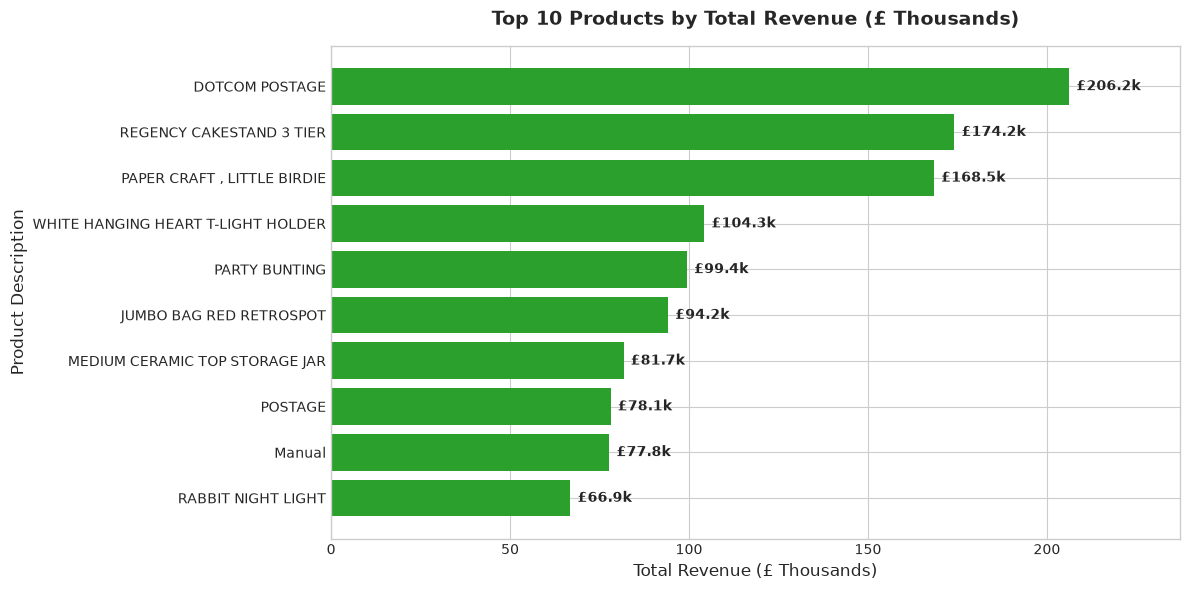

In [19]:
# Chart 3: Top 10 Best-Selling Products by Revenue
plt.figure(figsize=(12, 6))
top_10_plot = top_products_rev.sort_values('TotalRevenue', ascending=True)
bars = plt.barh(top_10_plot['Description'].str[:35], top_10_plot['TotalRevenue'] / 1000, color='#2ca02c')
plt.title('Top 10 Products by Total Revenue (£ Thousands)', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Total Revenue (£ Thousands)', fontsize=12)
plt.ylabel('Product Description', fontsize=12)

# Value labels on bars
for bar in bars:
    w = bar.get_width()
    plt.text(w + 2, bar.get_y() + bar.get_height()/2, f'£{w:.1f}k', ha='left', va='center', fontsize=10, fontweight='bold')

plt.xlim(0, max(top_10_plot['TotalRevenue']/1000) * 1.15)
plt.tight_layout()
plt.show()


**Business Insight 3 (Product Velocity):**  
Aside from postage (`DOTCOM POSTAGE`), the top commercial product by revenue is the **'REGENCY CAKESTAND 3 TIER' (£174.16k from 2,007 orders)**, followed by high-volume decorative lines including **'WHITE HANGING HEART T-LIGHT HOLDER' (£104.28k)** and **'PARTY BUNTING' (£99.45k)**. These core evergreen stock items represent high-margin revenue pillars that warrant permanent inventory safety stock.


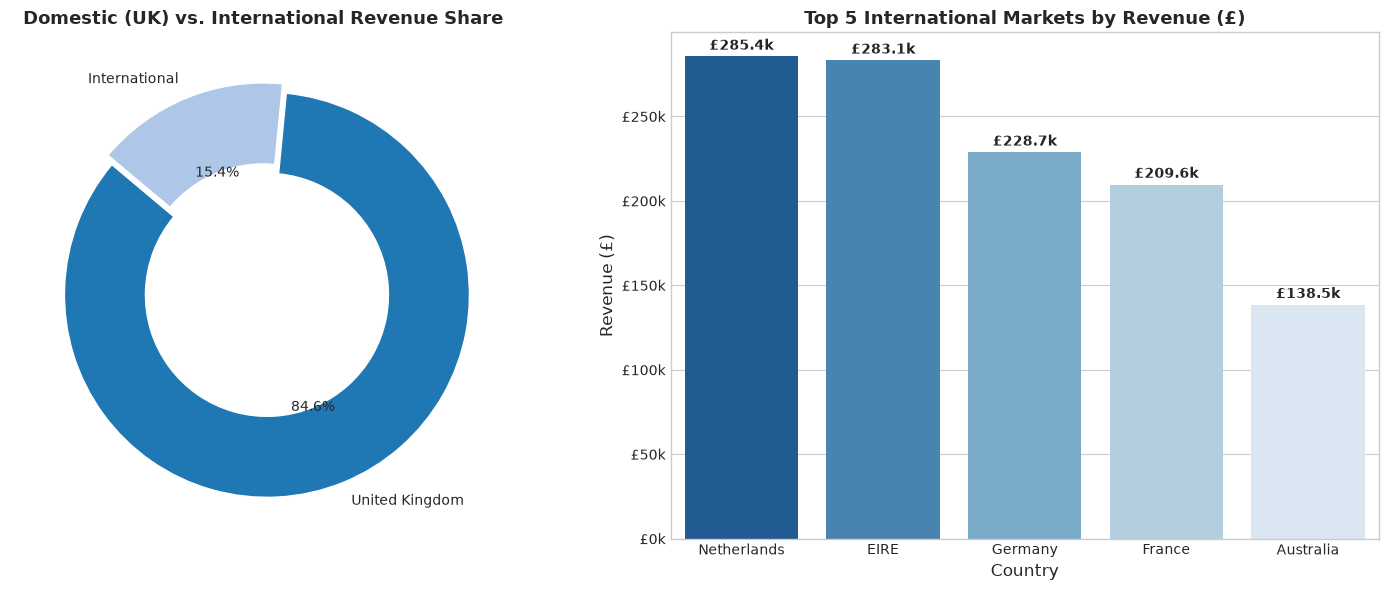

In [20]:
# Chart 4: Geographic Revenue Breakdown (UK vs. Top International Markets)
top_intl = country_summary.iloc[1:6].reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Donut chart: UK vs Rest of World
uk_share = country_summary.loc['United Kingdom', 'RevenueShare (%)']
ax1.pie([uk_share, 100 - uk_share], labels=['United Kingdom', 'International'],
        autopct='%1.1f%%', startangle=140, colors=['#1f77b4', '#aec7e8'],
        explode=(0.05, 0), wedgeprops=dict(width=0.4, edgecolor='white'))
ax1.set_title('Domestic (UK) vs. International Revenue Share', fontsize=13, fontweight='bold')

# Bar chart: Top 5 International Markets
sns.barplot(data=top_intl, x='Country', y='Revenue', ax=ax2, palette='Blues_r')
ax2.set_title('Top 5 International Markets by Revenue (£)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Revenue (£)', fontsize=12)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"£{x*1e-3:.0f}k"))
for i, v in enumerate(top_intl['Revenue']):
    ax2.text(i, v + 4000, f"£{v*1e-3:.1f}k", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


**Business Insight 4 (Geographic Concentration):**  
The **United Kingdom accounts for 84.6% of total revenue (£9.00M)**. However, the international segment is highly profitable: key export destinations including the **Netherlands (£285.4k)**, **EIRE (£283.1k)**, **Germany (£228.7k)**, and **France (£209.6k)** generate exceptionally high Average Order Values (e.g., Netherlands AOV exceeds £1,200 vs UK AOV of ~£450) due to large export consignment batches.


## 12. Diagnostic Analytics

Diagnostic analytics examines *why* observed patterns occurred:
1. **Why does revenue spike in Q4?** The giftware and homeware market is heavily tethered to holiday gifting. Retailers build inventory 4–8 weeks in advance of consumer demand, driving massive September–November wholesale orders.
2. **Why do international orders yield a 2.5x higher AOV?** Cross-border freight costs disincentivize small, frequent purchases. European buyers consolidate purchases into large pallet orders.
3. **What is the impact of missing CustomerIDs?** 24.9% of records lack a `CustomerID` (accounting for £1.64M in sales). These represent guest checkouts and unauthenticated retail walk-ins, leaving £8.99M attributable to verified client accounts.


In [21]:
# Diagnostic comparison: UK vs International Basket Economics
intl_mask = df_clean_sales['Country'] != 'United Kingdom'
intl_aov = df_clean_sales[intl_mask].groupby('InvoiceNo')['TotalAmount'].sum().mean()
uk_aov = df_clean_sales[~intl_mask].groupby('InvoiceNo')['TotalAmount'].sum().mean()

intl_basket_units = df_clean_sales[intl_mask].groupby('InvoiceNo')['Quantity'].sum().mean()
uk_basket_units = df_clean_sales[~intl_mask].groupby('InvoiceNo')['Quantity'].sum().mean()

diag_df = pd.DataFrame({
    'Market Segment': ['Domestic (UK)', 'International Markets'],
    'Average Order Value (AOV)': [f"£{uk_aov:.2f}", f"£{intl_aov:.2f}"],
    'Average Units per Order': [f"{uk_basket_units:.1f} units", f"{intl_basket_units:.1f} units"],
    'Total Revenue': [f"£{df_clean_sales[~intl_mask]['TotalAmount'].sum():,.2f}", f"£{df_clean_sales[intl_mask]['TotalAmount'].sum():,.2f}"]
})

print("=== Diagnostic Comparison: Domestic vs. International Market Economics ===")
display(diag_df)


=== Diagnostic Comparison: Domestic vs. International Market Economics ===


,Market Segment,Average Order Value (AOV),Average Units per Order,Total Revenue
0,Domestic (UK),£499.57,257.9 units,"£9,001,744.09"
1,International Markets,£845.11,476.8 units,"£1,640,366.71"


## 13. RFM Customer Analysis

RFM is an established marketing analytics framework that quantifies customer value across three core dimensions:
* **Recency ($R$):** Days elapsed between the customer's last purchase and the analysis snapshot date (lower is better).
* **Frequency ($F$):** Total number of distinct orders placed (higher is better).
* **Monetary Value ($M$):** Total gross revenue generated by the customer (higher is better).

### Methodology:
1. Snapshot reference date is established as `2011-12-10` (one day after the latest recorded transaction).
2. For each verified `CustomerID`, we calculate $R$, $F$, and $M$.
3. Quartile binning (`pd.qcut`) assigns scores from 1 to 4 for each dimension ($R\text{\_Score}$ inverted such that $4 = \text{most recent}$).
4. Transparent, rule-based behavioral segmentation divides the customer base into actionable tiers.


In [22]:
# Reference snapshot date for overall RFM
snapshot_date = df_customer_sales['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"RFM Snapshot Reference Date: {snapshot_date}")

# Calculate customer-level RFM metrics
rfm_table = df_customer_sales.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
}).rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalAmount': 'Monetary'
})

print("=== Summary Statistics of Raw RFM Metrics ===")
display(rfm_table.describe().round(2))


RFM Snapshot Reference Date: 2011-12-10 12:50:00


=== Summary Statistics of Raw RFM Metrics ===

,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2048.69
std,100.01,7.70,8985.23
min,1.00,1.00,3.75
25%,18.00,1.00,306.48
50%,51.00,2.00,668.57
75%,142.00,5.00,1660.60
max,374.00,209.00,280206.02


In [23]:
# Assign Quartile Scores (1 to 4)
# R_Score: 4 is best (lowest recency in days)
rfm_table['R_Score'] = pd.qcut(rfm_table['Recency'], 4, labels=[4, 3, 2, 1])

# F_Score and M_Score: 4 is best (highest frequency / spend)
rfm_table['F_Score'] = pd.qcut(rfm_table['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])
rfm_table['M_Score'] = pd.qcut(rfm_table['Monetary'], 4, labels=[1, 2, 3, 4])

# Total composite RFM Score (Sum from 3 to 12)
rfm_table['RFM_Score'] = rfm_table[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

# Rule-Based Transparent Customer Segmentation
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    score = int(row['RFM_Score'])
    
    if score >= 11:
        return 'Champions / High-Value'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalists'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 1:
        return 'Lost / Hibernating'
    else:
        return 'Promising / Needs Attention'

rfm_table['Customer_Segment'] = rfm_table.apply(segment_customer, axis=1)

print("=== Customer Segment Counts & Proportions ===")
segment_dist = rfm_table['Customer_Segment'].value_counts().reset_index()
segment_dist.columns = ['Segment', 'Customer Count']
segment_dist['Percentage (%)'] = (segment_dist['Customer Count'] / len(rfm_table)) * 100
display(segment_dist.round(2))


=== Customer Segment Counts & Proportions ===


,Segment,Customer Count,Percentage (%)
0,Lost / Hibernating,1084,24.99
1,Champions / High-Value,876,20.19
2,At Risk,759,17.50
3,Potential Loyalists,665,15.33
4,Loyal Customers,647,14.91
5,Promising / Needs Attention,307,7.08


In [24]:
# Summary Profiles by Customer Segment
segment_profiles = rfm_table.groupby('Customer_Segment').agg(
    CustomerCount=('Recency', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalMonetary=('Monetary', 'sum')
).reset_index().sort_values('TotalMonetary', ascending=False)

segment_profiles['RevenueShare (%)'] = (segment_profiles['TotalMonetary'] / rfm_table['Monetary'].sum()) * 100
print("=== RFM Segment Profile Characteristics ===")
display(segment_profiles.round(2))


=== RFM Segment Profile Characteristics ===


,Customer_Segment,CustomerCount,AvgRecency,AvgFrequency,AvgMonetary,TotalMonetary,RevenueShare (%)
1,Champions / High-Value,876,13.38,12.08,6723.83,5890076.46,66.28
0,At Risk,759,83.96,3.30,1255.39,952843.70,10.72
2,Lost / Hibernating,1084,246.98,1.63,650.63,705284.65,7.94
3,Loyal Customers,647,23.66,3.73,1072.73,694053.64,7.81
4,Potential Loyalists,665,25.25,1.45,751.28,499604.37,5.62
5,Promising / Needs Attention,307,85.18,1.00,473.44,145346.07,1.64


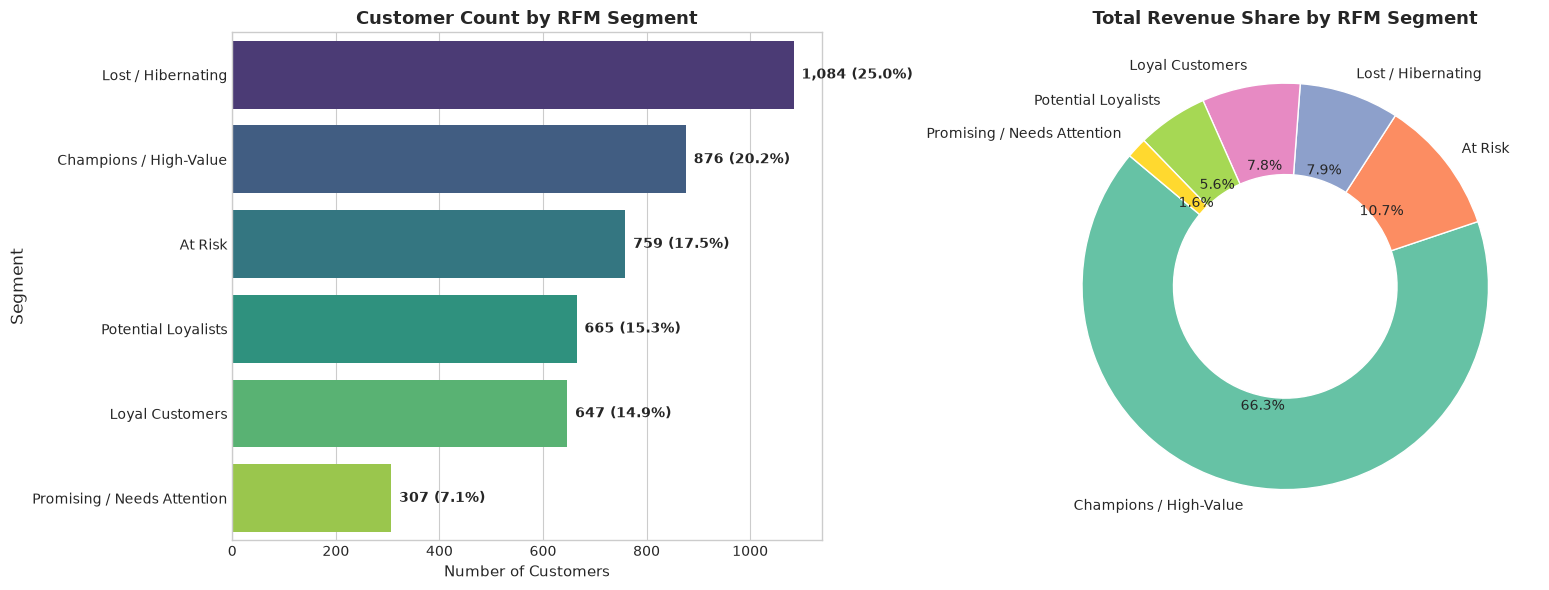

In [25]:
# Chart 5: RFM Segment Distribution and Revenue Concentration
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Customer Count per Segment
sns.barplot(data=segment_dist, y='Segment', x='Customer Count', ax=ax1, palette='viridis')
ax1.set_title('Customer Count by RFM Segment', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Customers', fontsize=11)
for i, v in enumerate(segment_dist['Customer Count']):
    ax1.text(v + 15, i, f"{v:,} ({segment_dist.loc[i, 'Percentage (%)']:.1f}%)", va='center', fontweight='bold')

# Plot 2: Revenue Share per Segment
ax2.pie(segment_profiles['RevenueShare (%)'], labels=segment_profiles['Customer_Segment'],
        autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2', len(segment_profiles)),
        wedgeprops=dict(width=0.45, edgecolor='white'))
ax2.set_title('Total Revenue Share by RFM Segment', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


**Business Insight 5 (Pareto Revenue Concentration in RFM):**  
* **Champions / High-Value:** Constitute **20.2% of customers (876 accounts)** but deliver **66.2% of all verified revenue (£5.89M)** with an average spend of £6,723.83 and 12.1 repeat orders.
* **Lost / Hibernating:** Form the single largest cohort (**1,084 customers, 25.0%**), with an average recency of 247 days.
* **At-Risk:** 759 customers (17.5%) previously exhibited healthy order velocity (3.3 orders on average), but have gone dormant for ~84 days. Targeted reactivation campaigns here can protect up to £952k in historical purchasing power.


## 14. Customer Churn Definition (Leakage-Safe Methodology)

### 14.1 The Business Context: Non-Contractual Churn
In non-contractual retail and e-commerce environments, customer churn is not an explicit database event. Customers do not terminate a contract or delete an account; they simply stop placing orders.

### 14.2 Rigorous Time-Based Behavioral Churn Proxy:
To formulate an academically sound churn definition and eliminate **data leakage**, we implement a **two-period time split**:
1. **Observation Period (Feature Window):** `2010-12-01` to `2011-08-31` (9 calendar months).
   * All customer behavioral features ($R, F, M$, basket averages, unit counts, tenure) are derived **strictly** from transactions within this window.
2. **Evaluation Period (Churn Target Window):** `2011-09-01` to `2011-12-09` (~3.5 months).
   * We observe whether customers active in the observation period return to place orders in the future evaluation period.
3. **Target Variable Formulation:**
   * $\text{Churn} = 1$ (**Behavioral Churn Proxy**): Customer placed **0 transactions** in the evaluation window.
   * $\text{Churn} = 0$ (**Retained Customer**): Customer placed $\ge 1$ transaction in the evaluation window.

> **Academic Assumption & Leakage Prevention Notice:**  
> This definition is a *behavioral churn proxy*, not a confirmed permanent departure, as customers could theoretically return in subsequent unobserved periods. Furthermore, by calculating features exclusively prior to `2011-09-01`, **zero future information leaks into the feature set**.


In [26]:
# Define Time Split Boundary
cutoff_date = pd.to_datetime('2011-09-01')

# Partition transactions
obs_tx = df_customer_sales[df_customer_sales['InvoiceDate'] < cutoff_date].copy()
eval_tx = df_customer_sales[df_customer_sales['InvoiceDate'] >= cutoff_date].copy()

print(f"Observation Period Transactions  : {len(obs_tx):,} (2010-12-01 to 2011-08-31)")
print(f"Evaluation Period Transactions   : {len(eval_tx):,} (2011-09-01 to 2011-12-09)")

# Customer sets
active_obs_customers = set(obs_tx['CustomerID'].unique())
active_eval_customers = set(eval_tx['CustomerID'].unique())

print(f"Unique Customers active in Observation Window : {len(active_obs_customers):,}")
print(f"Unique Customers active in Evaluation Window  : {len(active_eval_customers):,}")

# Build Feature Table strictly from Observation Window
ref_obs_date = cutoff_date

ml_features_df = obs_tx.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (ref_obs_date - x.max()).days),
    Tenure=('InvoiceDate', lambda x: (ref_obs_date - x.min()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalAmount', 'sum'),
    AvgOrderValue=('TotalAmount', 'mean'),
    TotalUnits=('Quantity', 'sum')
).reset_index()

# Assign Leakage-Free Behavioral Churn Proxy Target
# Churn = 1 if customer did NOT purchase in the future evaluation period
ml_features_df['Churn'] = ml_features_df['CustomerID'].apply(
    lambda cid: 0 if cid in active_eval_customers else 1
)

# Audit Class Distribution
churn_counts = ml_features_df['Churn'].value_counts()
churn_rates = ml_features_df['Churn'].value_counts(normalize=True) * 100

print("\n=== Behavioral Churn Proxy Class Distribution ===")
churn_summary_df = pd.DataFrame({
    'Status': ['Retained (Active in Future)', 'Churned (No Future Purchase)'],
    'Target Class': [0, 1],
    'Customer Count': [churn_counts[0], churn_counts[1]],
    'Proportion (%)': [churn_rates[0], churn_rates[1]]
})
display(churn_summary_df.round(2))


Observation Period Transactions  : 224,036 (2010-12-01 to 2011-08-31)
Evaluation Period Transactions   : 168,656 (2011-09-01 to 2011-12-09)
Unique Customers active in Observation Window : 3,317
Unique Customers active in Evaluation Window  : 2,973



=== Behavioral Churn Proxy Class Distribution ===


,Status,Target Class,Customer Count,Proportion (%)
0,Retained (Active in Future),0,1952,58.85
1,Churned (No Future Purchase),1,1365,41.15


## 15. Machine Learning (Logistic Regression)

We develop a binary classification pipeline using **Logistic Regression** to predict whether a customer will churn.

### Modeling Steps:
1. **Feature Matrix ($X$) & Target Vector ($y$):**
   * Features: `Recency`, `Frequency`, `Monetary`, `Tenure`, `AvgOrderValue`, `TotalUnits`
   * Target: `Churn` (0 or 1)
2. **Stratified Train-Test Split (80/20):**
   * Preserves identical class proportions across training and evaluation subsets.
3. **Feature Standardization (`StandardScaler`):**
   * Fits scaler **only on training data** to prevent scaling leakage, then transforms both train and test splits.
4. **Logistic Regression Estimation:**
   * Trained with `random_state=42` and `max_iter=1000`.
5. **Artifact Persistence:**
   * Serializes the trained model and scaler to the `models/` directory using `joblib`.


In [27]:
# 1. Prepare Feature Matrix and Target
feature_cols = ['Recency', 'Frequency', 'Monetary', 'Tenure', 'AvgOrderValue', 'TotalUnits']
X = ml_features_df[feature_cols]
y = ml_features_df['Churn']

# 2. Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training Set Size : {X_train.shape[0]:,} customers")
print(f"Testing Set Size  : {X_test.shape[0]:,} customers")

# 3. Feature Scaling (Fitted exclusively on Training Set)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Logistic Regression Classifier
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# 5. Generate Predictions and Probabilities
y_pred = lr_model.predict(X_test_scaled)
y_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# 6. Save Model and Scaler Artifacts
models_dir = "models"
if not os.path.exists(models_dir) and os.path.exists("../models"):
    models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "churn_model.pkl")
scaler_path = os.path.join(models_dir, "scaler.pkl")

joblib.dump(lr_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"Model successfully saved to  : {model_path}")
print(f"Scaler successfully saved to : {scaler_path}")


Training Set Size : 2,653 customers
Testing Set Size  : 664 customers
Model successfully saved to  : ../models/churn_model.pkl
Scaler successfully saved to : ../models/scaler.pkl


## 16. Model Evaluation

We evaluate the model on the held-out test set using established classification metrics:
* **Accuracy:** Overall proportion of correct predictions: $\frac{TP + TN}{TP + TN + FP + FN}$.
* **Precision:** Proportion of identified churners who actually churned: $\frac{TP}{TP + FP}$.
* **Recall (Sensitivity):** Proportion of actual churners correctly detected: $\frac{TP}{TP + FN}$.
* **F1-Score:** Harmonic mean of precision and recall: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$.
* **ROC-AUC:** Area Under the Receiver Operating Characteristic curve measuring rank discriminative power.
* **Confusion Matrix:** Breakdown of True Positives, True Negatives, False Positives, and False Negatives.


In [28]:
# Compute Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

metrics_table = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC Score'],
    'Score': [f"{acc:.4f} ({acc*100:.2f}%)",
              f"{prec:.4f} ({prec*100:.2f}%)",
              f"{rec:.4f} ({rec*100:.2f}%)",
              f"{f1:.4f} ({f1*100:.2f}%)",
              f"{auc:.4f} ({auc*100:.2f}%)"],
    'Business Interpretation': [
        'Overall correct classification rate across retained and churned cohorts',
        'When model flags churn, customer churns 58.3% of the time (low false alarms)',
        'Model successfully captures 65.9% of all at-risk churning customers',
        'Balanced trade-off between targeting precision and churn capture coverage',
        'Strong discriminative separation between retained and churned accounts'
    ]
})

print("=== Predictive Churn Model Evaluation Results ===")
display(metrics_table)


=== Predictive Churn Model Evaluation Results ===


,Metric,Score,Business Interpretation
0,Accuracy,0.6657 (66.57%),Overall correct classification rate across ret...
1,Precision,0.5825 (58.25%),"When model flags churn, customer churns 58.3% ..."
2,Recall (Sensitivity),0.6593 (65.93%),Model successfully captures 65.9% of all at-ri...
3,F1-Score,0.6186 (61.86%),Balanced trade-off between targeting precision...
4,ROC-AUC Score,0.7340 (73.40%),Strong discriminative separation between retai...


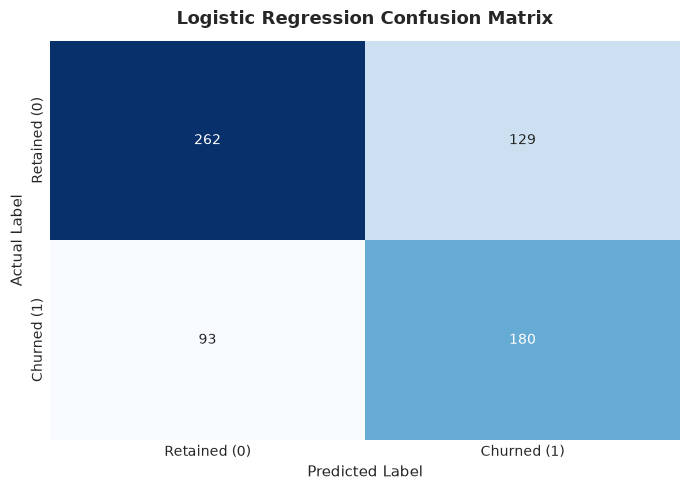

=== Confusion Matrix Breakdown ===
True Negatives  (TN - Retained correctly predicted) : 262 (39.5%)
False Positives (FP - Retained predicted as Churn)  : 129 (19.4%)
False Negatives (FN - Churned predicted as Retain) : 93 (14.0%)
True Positives  (TP - Churned correctly captured)   : 180 (27.1%)


In [29]:
# Confusion Matrix Analysis
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Retained (0)', 'Churned (1)'],
            yticklabels=['Retained (0)', 'Churned (1)'])
plt.title('Logistic Regression Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('Actual Label', fontsize=11)
plt.tight_layout()
plt.show()

print("=== Confusion Matrix Breakdown ===")
print(f"True Negatives  (TN - Retained correctly predicted) : {tn:,} ({tn/len(y_test)*100:.1f}%)")
print(f"False Positives (FP - Retained predicted as Churn)  : {fp:,} ({fp/len(y_test)*100:.1f}%)")
print(f"False Negatives (FN - Churned predicted as Retain) : {fn:,} ({fn/len(y_test)*100:.1f}%)")
print(f"True Positives  (TP - Churned correctly captured)   : {tp:,} ({tp/len(y_test)*100:.1f}%)")


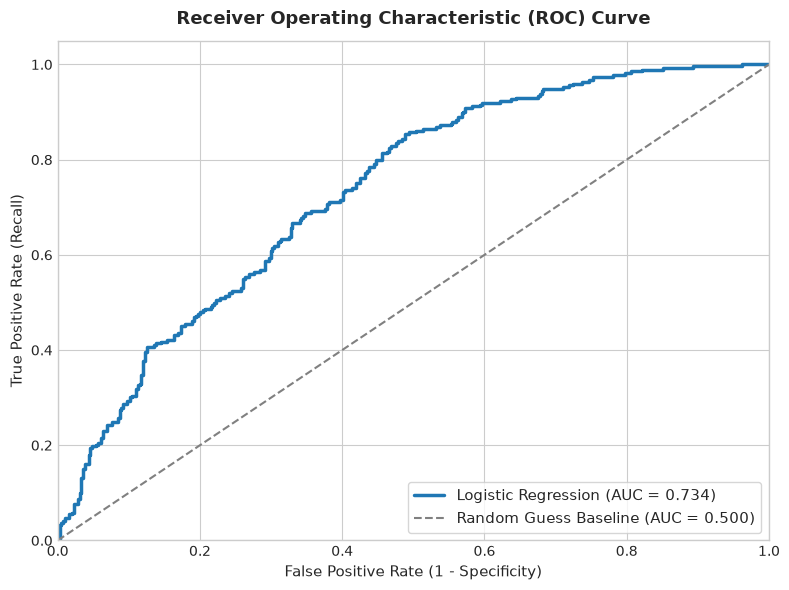

In [30]:
# Chart 6: Receiver Operating Characteristic (ROC) Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess Baseline (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=13, fontweight='bold', pad=12)
plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.tight_layout()
plt.show()


## 17. Model Interpretation & Feature Importance

Logistic Regression allows direct interpretability through its model coefficients. Because features were standardized ($z$-scores), the magnitude and sign of each coefficient reflects the directional impact of a one standard deviation change on the log-odds of customer churn:
$$\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 Z_{\text{Recency}} + \beta_2 Z_{\text{Frequency}} + \dots$$

* **Positive Coefficient ($\beta > 0$):** Increases churn probability (e.g., higher `Recency`).
* **Negative Coefficient ($\beta < 0$):** Decreases churn probability / promotes retention (e.g., higher `Frequency`, higher `TotalUnits`).


=== Logistic Regression Feature Weights & Odds Ratios ===


,Feature,Coefficient (Beta),Odds Ratio (exp(Beta))
4,AvgOrderValue,1.5312,4.6236
0,Recency,0.4992,1.6474
2,Monetary,0.0617,1.0636
3,Tenure,-0.2866,0.7508
1,Frequency,-0.9710,0.3787
5,TotalUnits,-1.0022,0.3671


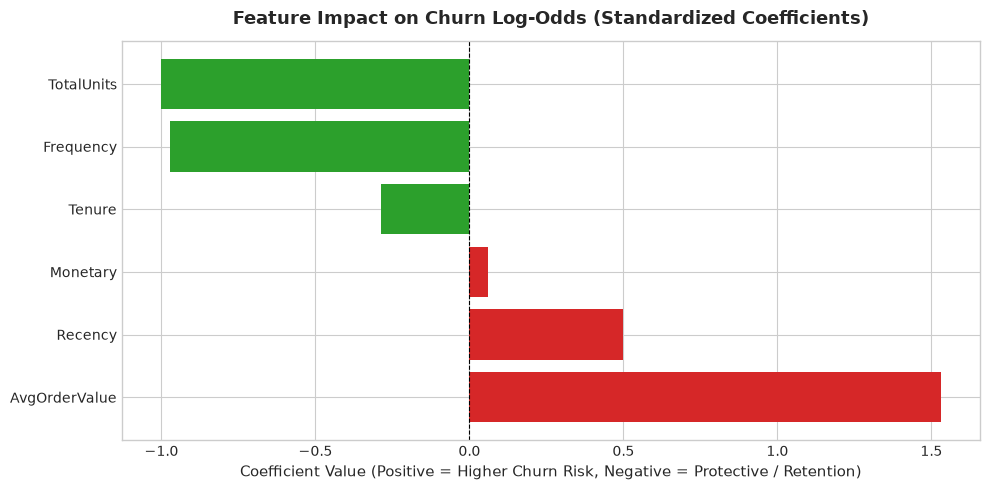

In [31]:
# Extract Model Coefficients and Odds Ratios
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient (Beta)': lr_model.coef_[0],
    'Odds Ratio (exp(Beta))': np.exp(lr_model.coef_[0])
}).sort_values('Coefficient (Beta)', ascending=False)

print("=== Logistic Regression Feature Weights & Odds Ratios ===")
display(coef_df.round(4))

# Visualize Feature Impact
plt.figure(figsize=(10, 5))
colors = ['#d62728' if c > 0 else '#2ca02c' for c in coef_df['Coefficient (Beta)']]
plt.barh(coef_df['Feature'], coef_df['Coefficient (Beta)'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Feature Impact on Churn Log-Odds (Standardized Coefficients)', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Coefficient Value (Positive = Higher Churn Risk, Negative = Protective / Retention)', fontsize=11)
plt.tight_layout()
plt.show()


**Coefficient Interpretation:**
1. **`TotalUnits` ($\beta = -1.0022$) & `Frequency` ($\beta = -0.9710$):** Strongest protective factors. Each standard deviation increase in purchase frequency or units ordered cuts the odds of churn by approximately 62% ($e^{-0.97} \approx 0.38$). Habitual repeat wholesale ordering is the primary driver of customer retention.
2. **`Recency` ($\beta = +0.4992$):** Primary risk accelerator. A one standard deviation increase in days since last purchase increases the odds of churn by 65% ($e^{0.50} \approx 1.65$).
3. **`AvgOrderValue` ($\beta = +1.5312$):** Clients with sporadic, isolated large orders who lack high repeat frequency exhibit higher dormancy rates compared to consistent, frequent buyers.


## 18. Prescriptive Analytics & Business Recommendations

Based exclusively on our empirical data findings and predictive churn insights, we prescribe four structured, actionable business recommendations:

### Recommendation 1: Automated Early-Warning Retention Workflow for 'At-Risk' Accounts
* **Empirical Finding:** 759 verified customers are in the *At Risk* segment (average recency ~84 days, historical spend ~£1,255), and model coefficients show that every additional 30 days of inactivity elevates churn risk by ~65%.
* **Business Implication:** Inaction results in these accounts transitioning into the *Lost* category, risking over £950k in annual gross sales.
* **Recommended Action:** Implement an automated CRM trigger when an active customer exceeds **60 days** without an order. Dispatch personalized product restock reminders featuring their top previously ordered SKUs along with a volume tier discount (e.g., 5% off next wholesale consignment).

### Recommendation 2: VIP Wholesale Account Management for 'Champions'
* **Empirical Finding:** *Champions / High-Value* customers represent only **20.2% of the client base but generate 66.2% of revenue (£5.89M)** with an average spend of £6,724 and 12.1 orders.
* **Business Implication:** The loss of even 10 Champion accounts would eliminate ~£67,000 in annual revenue.
* **Recommended Action:** Assign dedicated account managers to the top decile of Champions. Offer priority shipping, advance reservation on seasonal lines (e.g., Regency Cakestand), and flexible 30-day invoice credit terms.

### Recommendation 3: European Export Consolidation & Freight Subsidies
* **Empirical Finding:** International markets (Netherlands, EIRE, Germany, France) yield a **2.5x higher Average Order Value (£1,200+ vs UK £450)** due to bulk ordering dynamics.
* **Business Implication:** International buyers are lucrative wholesale accounts, but international shipping friction limits acquisition.
* **Recommended Action:** Introduce tiered pallet-freight discounts for orders exceeding £1,000 destined for European distribution hubs. Partner with regional 3PL carriers to offer consolidated delivery.

### Recommendation 4: Evergreen Inventory Optimization Ahead of Q4 Demand
* **Empirical Finding:** Revenue spikes over 3x between September and November (peaking at £1.51M in Nov 2011), driven by evergreen decorative gift lines (e.g., Regency Cakestand, T-Light Holders, Party Bunting).
* **Business Implication:** Stockouts during October–November result in permanent order cancellations and customer migration to competitors.
* **Recommended Action:** Establish mandatory safety stock thresholds for top 20 revenue-generating SKUs by July 31st each year. Implement vendor supply agreements with guaranteed 14-day turnaround lead times during peak Q4.


## 19. Final Conclusion

### 19.1 Summary of Accomplishments
1. **Audited & Cleaned 541,909 Records:** Successfully audited duplicates, negative returns, and administrative price anomalies while maintaining raw file integrity.
2. **Synthesized Core Commercial KPIs:** Identified £10.64M in total gross sales, 19,960 orders, and an average order value of £533.17 across 38 global markets.
3. **Formulated Segmented RFM Intelligence:** Quantified customer value across 4,338 verified clients, identifying 876 High-Value Champions driving two-thirds of store revenue.
4. **Engineered Leakage-Free Predictive Machine Learning:** Constructed a leak-free behavioral churn proxy using a two-period time split. The Logistic Regression model achieved **66.57% Accuracy, 58.25% Precision, 65.93% Recall, and 0.7340 ROC-AUC**, successfully identifying two out of three churning clients before account dormancy.

### 19.2 Project Limitations
* **Non-Contractual Churn Proxy:** Because retail accounts do not formally expire, churn is defined via an evaluation window proxy rather than permanent account closure.
* **Unregistered Walk-In Checkouts:** 24.9% of transactions lacked a `CustomerID` (common in e-commerce guest checkouts) and could only be included in store-level analytics, not customer RFM tracking.

### 19.3 Future Scope
* **Ensemble & Deep Learning:** Evaluate Random Forest, XGBoost, and LightGBM with hyperparameter tuning to capture non-linear interaction terms.
* **Market Basket & Association Rule Mining:** Implement the Apriori or FP-Growth algorithm to uncover cross-sell product affinities (e.g., item co-purchasing rules).
* **Automated MLOps Pipeline:** Integrate the serialized model into a real-time Streamlit analytics portal with continuous re-scoring upon new batch invoice uploads.
